<a href="https://colab.research.google.com/github/Dokkae-bi/Intro-to-DL-Summer-26/blob/main/Homework3/Homework_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Homework 3: Sequence-to-Sequence Machine Translation

Problem 1: Baseline Encoder-Decoder Architecture (30 Points)

Setup and Special Tokens

In [ ]:
import re, random
import torch
from torch.utils.data import Dataset, DataLoader

random.seed(42)          # set once so the 80/20 split is identical across P1, P2, P3
torch.manual_seed(42)

PAD, SOS, EOS, UNK = 0, 1, 2, 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

load, normalize, split

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/vast_english_french.txt"

def normalize(s):
    s = s.lower().strip()
    s = re.sub(r"([?.!,'])", r" \1 ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

raw = open(DATA_PATH, encoding="utf-8").read().splitlines()
pairs = [tuple(normalize(x) for x in line.split("\t"))
         for line in raw if line.count("\t") == 1]

random.shuffle(pairs)
n_val = int(0.2 * len(pairs))
val_pairs   = pairs[:n_val]
train_pairs = pairs[n_val:]
print(f"{len(pairs)} pairs -> {len(train_pairs)} train / {len(val_pairs)} val")

Mounted at /content/drive
555 pairs -> 444 train / 111 val


vocab, built from the training split only

In [ ]:
class Vocab:
    def __init__(self):
        self.word2idx = {"<PAD>": PAD, "<SOS>": SOS, "<EOS>": EOS, "<UNK>": UNK}
        self.idx2word = {i: w for w, i in self.word2idx.items()}
    def add_sentence(self, s):
        for w in s.split():
            if w not in self.word2idx:
                i = len(self.word2idx)
                self.word2idx[w] = i
                self.idx2word[i] = w
    def __len__(self):
        return len(self.word2idx)
    def encode(self, s, add_eos=True):
        ids = [self.word2idx.get(w, UNK) for w in s.split()]   # unseen word -> <UNK>
        return ids + [EOS] if add_eos else ids
    def decode(self, ids):
        return " ".join(self.idx2word[i] for i in ids if i not in (PAD, SOS, EOS))

eng_vocab, fr_vocab = Vocab(), Vocab()
for en, fr in train_pairs:
    eng_vocab.add_sentence(en)
    fr_vocab.add_sentence(fr)
print(f"English vocab: {len(eng_vocab)} | French vocab: {len(fr_vocab)}")

English vocab: 881 | French vocab: 970


direction-agnostic Dataset + loaders

In [ ]:
class TranslationDataset(Dataset):
    """src_is_english=True -> EN->FR (P1/P2). Set False for FR->EN (P3)."""
    def __init__(self, pairs, src_vocab, tgt_vocab, src_is_english=True):
        self.pairs = pairs
        self.src_vocab, self.tgt_vocab = src_vocab, tgt_vocab
        self.src_is_english = src_is_english
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, i):
        en, fr = self.pairs[i]
        src_txt, tgt_txt = (en, fr) if self.src_is_english else (fr, en)
        src = torch.tensor(self.src_vocab.encode(src_txt), dtype=torch.long)
        tgt = torch.tensor(self.tgt_vocab.encode(tgt_txt), dtype=torch.long)
        return src, tgt

# English -> French (Problems 1 & 2)
train_ds = TranslationDataset(train_pairs, eng_vocab, fr_vocab, src_is_english=True)
val_ds   = TranslationDataset(val_pairs,   eng_vocab, fr_vocab, src_is_english=True)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False)

Sanity Check

In [ ]:
def unk_rate(pairs, vocab, use_english):
    tot = unk = 0
    for en, fr in pairs:
        for w in (en if use_english else fr).split():
            tot += 1
            unk += (w not in vocab.word2idx)
    return 100 * unk / tot

print(f"Val English UNK rate: {unk_rate(val_pairs, eng_vocab, True):.1f}%")
print(f"Val French  UNK rate: {unk_rate(val_pairs, fr_vocab, False):.1f}%")

src, tgt = next(iter(train_loader))
print("\nbatch shapes:", src.shape, tgt.shape)
print("decoded:", eng_vocab.decode(src[0].tolist()), "->", fr_vocab.decode(tgt[0].tolist()))

Val English UNK rate: 20.2%
Val French  UNK rate: 19.2%

batch shapes: torch.Size([1, 8]) torch.Size([1, 11])
decoded: she works full-time at the general hospital -> elle travaille à plein temps à l ' hôpital général


Architecture the GRU encoder and baseline decoder

In [ ]:
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

class EncoderGRU(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)          # GRU hidden is ONE tensor, no (h,c)
    def forward(self, x, hidden):
        embedded = self.embedding(x).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        return output, hidden
    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)   # single tensor for GRU

class DecoderGRU(nn.Module):
    def __init__(self, hidden_size, output_size):
        super().__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)       # raw logits -> CrossEntropyLoss
    def forward(self, x, hidden):
        embedded = self.embedding(x).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        logits = self.out(output[0])                         # (1, output_size)
        return logits, hidden

train / val-loss / decode / evaluate functions

In [ ]:
teacher_forcing_ratio = 0.5
smooth = SmoothingFunction().method1

def train_step(src, tgt, encoder, decoder, enc_opt, dec_opt, criterion):
    enc_hidden = encoder.initHidden()
    enc_opt.zero_grad(); dec_opt.zero_grad()
    for ei in range(src.size(0)):                            # read the source
        _, enc_hidden = encoder(src[ei].unsqueeze(0), enc_hidden)
    dec_input = torch.tensor([[SOS]], device=device)
    dec_hidden = enc_hidden                                  # context vector handoff
    use_tf = random.random() < teacher_forcing_ratio
    loss = 0
    for di in range(tgt.size(0)):
        logits, dec_hidden = decoder(dec_input, dec_hidden)
        loss += criterion(logits, tgt[di].unsqueeze(0))
        if use_tf:
            dec_input = tgt[di].view(1, 1)                   # feed ground truth
        else:
            dec_input = logits.argmax(1).view(1, 1).detach() # feed own prediction
    loss.backward()
    enc_opt.step(); dec_opt.step()
    return loss.item() / tgt.size(0)

def val_loss(encoder, decoder, loader, criterion):
    encoder.eval(); decoder.eval(); total = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src[0].to(device), tgt[0].to(device)
            enc_hidden = encoder.initHidden()
            for ei in range(src.size(0)):
                _, enc_hidden = encoder(src[ei].unsqueeze(0), enc_hidden)
            dec_input = torch.tensor([[SOS]], device=device)
            dec_hidden = enc_hidden; loss = 0
            for di in range(tgt.size(0)):
                logits, dec_hidden = decoder(dec_input, dec_hidden)
                loss += criterion(logits, tgt[di].unsqueeze(0))
                dec_input = tgt[di].view(1, 1)               # teacher-forced for a comparable curve
            total += loss.item() / tgt.size(0)
    encoder.train(); decoder.train()
    return total / len(loader)

def greedy_decode(encoder, decoder, src, max_len=20):
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        enc_hidden = encoder.initHidden()
        for ei in range(src.size(0)):
            _, enc_hidden = encoder(src[ei].unsqueeze(0), enc_hidden)
        dec_input = torch.tensor([[SOS]], device=device)
        dec_hidden = enc_hidden; ids = []
        for _ in range(max_len):                             # cap, NOT target length
            logits, dec_hidden = decoder(dec_input, dec_hidden)
            top = logits.argmax(1).item()
            if top == EOS: break
            ids.append(top)
            dec_input = torch.tensor([[top]], device=device)
    return ids

def evaluate(encoder, decoder, pairs, src_vocab, tgt_vocab, src_is_english=True, n_examples=5):
    exact = 0; bleu_total = 0.0; examples = []
    for idx, (en, fr) in enumerate(pairs):
        src_txt, tgt_txt = (en, fr) if src_is_english else (fr, en)
        src = torch.tensor(src_vocab.encode(src_txt), dtype=torch.long, device=device)
        ids = greedy_decode(encoder, decoder, src)
        pred_words = [tgt_vocab.idx2word[i] for i in ids]
        tgt_words = tgt_txt.split()
        is_exact = pred_words == tgt_words
        exact += is_exact
        b = sentence_bleu([tgt_words], pred_words, smoothing_function=smooth) if pred_words else 0.0
        bleu_total += b
        if idx < n_examples:
            examples.append((src_txt, tgt_txt, " ".join(pred_words), is_exact, b))
    n = len(pairs)
    print(f"Exact-match accuracy : {100*exact/n:.2f}%  ({exact}/{n})")
    print(f"Average BLEU-4        : {bleu_total/n:.4f}\n")
    for s, t, p, e, b in examples:
        print(f"[{'PASS' if e else 'FAIL'}] BLEU {b:.3f}")
        print(f"  in  : {s}\n  tgt : {t}\n  pred: {p}\n")
    return 100*exact/n, bleu_total/n

instantiate, train, and plot the curves

epoch 01 | train 5.2479 | val 4.6581
epoch 05 | train 1.8468 | val 4.2737
epoch 10 | train 0.2241 | val 4.4531
epoch 15 | train 0.0647 | val 4.7011
epoch 20 | train 0.0819 | val 4.9314
epoch 25 | train 0.0301 | val 5.0949
epoch 30 | train 0.1094 | val 5.2338
epoch 35 | train 0.0108 | val 5.3730
epoch 40 | train 0.0050 | val 5.5201


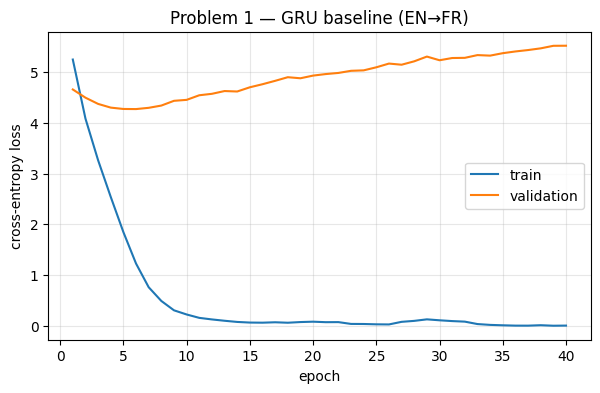

In [ ]:
hidden_size = 256
encoder = EncoderGRU(len(eng_vocab), hidden_size).to(device)
decoder = DecoderGRU(hidden_size, len(fr_vocab)).to(device)
criterion = nn.CrossEntropyLoss()
enc_opt = optim.Adam(encoder.parameters(), lr=0.001)         # Adam >> the toy's SGD here
dec_opt = optim.Adam(decoder.parameters(), lr=0.001)

n_epochs = 40
train_losses, val_losses = [], []
for epoch in range(1, n_epochs + 1):
    encoder.train(); decoder.train(); running = 0
    for src, tgt in train_loader:
        src, tgt = src[0].to(device), tgt[0].to(device)
        running += train_step(src, tgt, encoder, decoder, enc_opt, dec_opt, criterion)
    train_losses.append(running / len(train_loader))
    val_losses.append(val_loss(encoder, decoder, val_loader, criterion))
    if epoch == 1 or epoch % 5 == 0:
        print(f"epoch {epoch:02d} | train {train_losses[-1]:.4f} | val {val_losses[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, n_epochs + 1), train_losses, label="train")
plt.plot(range(1, n_epochs + 1), val_losses, label="validation")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss")
plt.title("Problem 1 — GRU baseline (EN→FR)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

final validation metrics and qualitative samples

In [ ]:
acc, bleu = evaluate(encoder, decoder, val_pairs, eng_vocab, fr_vocab, src_is_english=True, n_examples=5)

Exact-match accuracy : 0.00%  (0/111)
Average BLEU-4        : 0.1262

[FAIL] BLEU 0.063
  in  : he teaches world geography to high school classes
  tgt : il enseigne la géographie mondiale à des classes de lycée
  pred: il enseigne l ' histoire à des enfants du collège

[FAIL] BLEU 0.905
  in  : he plays bass guitar in a professional jazz band
  tgt : il joue de la basse dans un groupe de jazz professionnel
  pred: il joue de la basse dans un groupe de jazz

[FAIL] BLEU 0.000
  in  : the weather forecast predicts heavy snow tomorrow
  tgt : les prévisions météo annoncent de fortes chutes de neige demain
  pred: le allons certainement à l ' aube le samedi

[FAIL] BLEU 0.139
  in  : she loves to wear long flowing cotton skirts
  tgt : elle adore porter de longues jupes amples en coton
  pred: elle adore porter des jupes longues

[FAIL] BLEU 0.024
  in  : they listen to the professor with absolute attention
  tgt : ils écoutent le professeur avec une attention absolue
  pred: ils nourriss

Problem 2: Sequence-to-Sequence with Attention (30 Points)

 6b — keeping the encoder and adding the attention decoder

In [ ]:
import torch.nn.functional as F

class AttnDecoderGRU(nn.Module):
    """Luong dot-product attention decoder."""
    def __init__(self, hidden_size, output_size):
        super().__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.attn_combine = nn.Linear(hidden_size * 2, hidden_size)  # fuse context + GRU output
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden, encoder_outputs):
        # encoder_outputs: (src_len, hidden) — ALL encoder states, not just the last
        embedded = self.embedding(x).view(1, 1, -1)
        gru_out, hidden = self.gru(embedded, hidden)          # gru_out: (1, 1, hidden)

        # Luong score: dot(decoder state, each encoder state) -> softmax over source positions
        scores = torch.matmul(encoder_outputs, gru_out[0, 0])  # (src_len,)
        attn_weights = F.softmax(scores, dim=0)                # (src_len,)
        context = torch.matmul(attn_weights, encoder_outputs)  # (hidden,)

        combined = torch.cat((gru_out[0, 0], context), dim=0)  # (2*hidden,)
        combined = torch.tanh(self.attn_combine(combined))     # (hidden,)
        logits = self.out(combined).unsqueeze(0)               # (1, output_size)
        return logits, hidden, attn_weights

7b — attention-aware train / val / decode / evaluate

In [ ]:
def encode_source(encoder, src):
    enc_hidden = encoder.initHidden()
    outputs = []
    for ei in range(src.size(0)):
        out, enc_hidden = encoder(src[ei].unsqueeze(0), enc_hidden)
        outputs.append(out[0, 0])                    # keep EVERY hidden state
    return torch.stack(outputs), enc_hidden          # (src_len, hidden), last hidden

def train_step_attn(src, tgt, encoder, decoder, enc_opt, dec_opt, criterion):
    enc_opt.zero_grad(); dec_opt.zero_grad()
    encoder_outputs, enc_hidden = encode_source(encoder, src)
    dec_input = torch.tensor([[SOS]], device=device)
    dec_hidden = enc_hidden
    use_tf = random.random() < teacher_forcing_ratio
    loss = 0
    for di in range(tgt.size(0)):
        logits, dec_hidden, _ = decoder(dec_input, dec_hidden, encoder_outputs)
        loss += criterion(logits, tgt[di].unsqueeze(0))
        dec_input = tgt[di].view(1, 1) if use_tf else logits.argmax(1).view(1, 1).detach()
    loss.backward()
    enc_opt.step(); dec_opt.step()
    return loss.item() / tgt.size(0)

def val_loss_attn(encoder, decoder, loader, criterion):
    encoder.eval(); decoder.eval(); total = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src[0].to(device), tgt[0].to(device)
            encoder_outputs, enc_hidden = encode_source(encoder, src)
            dec_input = torch.tensor([[SOS]], device=device)
            dec_hidden = enc_hidden; loss = 0
            for di in range(tgt.size(0)):
                logits, dec_hidden, _ = decoder(dec_input, dec_hidden, encoder_outputs)
                loss += criterion(logits, tgt[di].unsqueeze(0))
                dec_input = tgt[di].view(1, 1)
            total += loss.item() / tgt.size(0)
    encoder.train(); decoder.train()
    return total / len(loader)

def greedy_decode_attn(encoder, decoder, src, max_len=20):
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        encoder_outputs, enc_hidden = encode_source(encoder, src)
        dec_input = torch.tensor([[SOS]], device=device)
        dec_hidden = enc_hidden; ids = []; attns = []
        for _ in range(max_len):
            logits, dec_hidden, attn_weights = decoder(dec_input, dec_hidden, encoder_outputs)
            attns.append(attn_weights.cpu())
            top = logits.argmax(1).item()
            if top == EOS: break
            ids.append(top)
            dec_input = torch.tensor([[top]], device=device)
    attn_matrix = torch.stack(attns) if attns else None       # (out_len, src_len)
    return ids, attn_matrix

def evaluate_attn(encoder, decoder, pairs, src_vocab, tgt_vocab, src_is_english=True, n_examples=5):
    exact = 0; bleu_total = 0.0; examples = []
    for idx, (en, fr) in enumerate(pairs):
        src_txt, tgt_txt = (en, fr) if src_is_english else (fr, en)
        src = torch.tensor(src_vocab.encode(src_txt), dtype=torch.long, device=device)
        ids, _ = greedy_decode_attn(encoder, decoder, src)
        pred_words = [tgt_vocab.idx2word[i] for i in ids]
        tgt_words = tgt_txt.split()
        is_exact = pred_words == tgt_words
        exact += is_exact
        b = sentence_bleu([tgt_words], pred_words, smoothing_function=smooth) if pred_words else 0.0
        bleu_total += b
        if idx < n_examples:
            examples.append((src_txt, tgt_txt, " ".join(pred_words), is_exact, b))
    n = len(pairs)
    print(f"Exact-match accuracy : {100*exact/n:.2f}%  ({exact}/{n})")
    print(f"Average BLEU-4        : {bleu_total/n:.4f}\n")
    for s, t, p, e, b in examples:
        print(f"[{'PASS' if e else 'FAIL'}] BLEU {b:.3f}\n  in  : {s}\n  tgt : {t}\n  pred: {p}\n")
    return 100*exact/n, bleu_total/n

8b — instantiate and train the attention model (fresh encoder so P1 and P2 are independent runs on the same data)

epoch 01 | train 5.4343 | val 4.7477
epoch 05 | train 2.1859 | val 4.3271
epoch 10 | train 0.5271 | val 4.5135
epoch 15 | train 0.2577 | val 4.8885
epoch 20 | train 0.2160 | val 5.0993
epoch 25 | train 0.0761 | val 5.2728
epoch 30 | train 0.1275 | val 5.5377
epoch 35 | train 0.1046 | val 5.6285
epoch 40 | train 0.0104 | val 5.8473


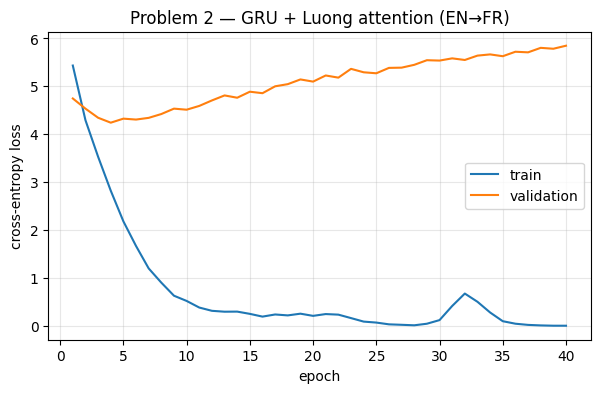

In [ ]:
hidden_size = 256
attn_encoder = EncoderGRU(len(eng_vocab), hidden_size).to(device)
attn_decoder = AttnDecoderGRU(hidden_size, len(fr_vocab)).to(device)
criterion = nn.CrossEntropyLoss()
enc_opt = optim.Adam(attn_encoder.parameters(), lr=0.001)
dec_opt = optim.Adam(attn_decoder.parameters(), lr=0.001)

n_epochs = 40
attn_train_losses, attn_val_losses = [], []
for epoch in range(1, n_epochs + 1):
    attn_encoder.train(); attn_decoder.train(); running = 0
    for src, tgt in train_loader:
        src, tgt = src[0].to(device), tgt[0].to(device)
        running += train_step_attn(src, tgt, attn_encoder, attn_decoder, enc_opt, dec_opt, criterion)
    attn_train_losses.append(running / len(train_loader))
    attn_val_losses.append(val_loss_attn(attn_encoder, attn_decoder, val_loader, criterion))
    if epoch == 1 or epoch % 5 == 0:
        print(f"epoch {epoch:02d} | train {attn_train_losses[-1]:.4f} | val {attn_val_losses[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, n_epochs + 1), attn_train_losses, label="train")
plt.plot(range(1, n_epochs + 1), attn_val_losses, label="validation")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss")
plt.title("Problem 2 — GRU + Luong attention (EN→FR)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

9b — metrics plus the required attention heatmaps

Exact-match accuracy : 0.90%  (1/111)
Average BLEU-4        : 0.1479

[FAIL] BLEU 0.021
  in  : he teaches world geography to high school classes
  tgt : il enseigne la géographie mondiale à des classes de lycée
  pred: il a fini son prestigieux pour

[FAIL] BLEU 0.905
  in  : he plays bass guitar in a professional jazz band
  tgt : il joue de la basse dans un groupe de jazz professionnel
  pred: il joue de la basse dans un groupe de jazz

[FAIL] BLEU 0.011
  in  : the weather forecast predicts heavy snow tomorrow
  tgt : les prévisions météo annoncent de fortes chutes de neige demain
  pred: le réparerai demain

[FAIL] BLEU 0.139
  in  : she loves to wear long flowing cotton skirts
  tgt : elle adore porter de longues jupes amples en coton
  pred: elle adore porter des jupes longues

[FAIL] BLEU 0.063
  in  : they listen to the professor with absolute attention
  tgt : ils écoutent le professeur avec une attention absolue
  pred: ils écoutent la pyramide



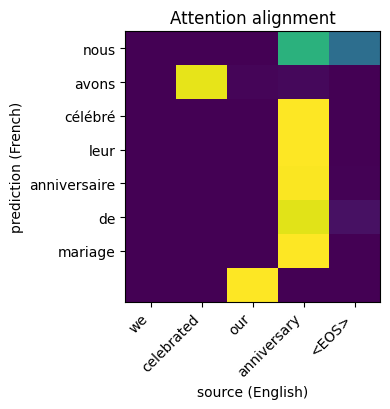

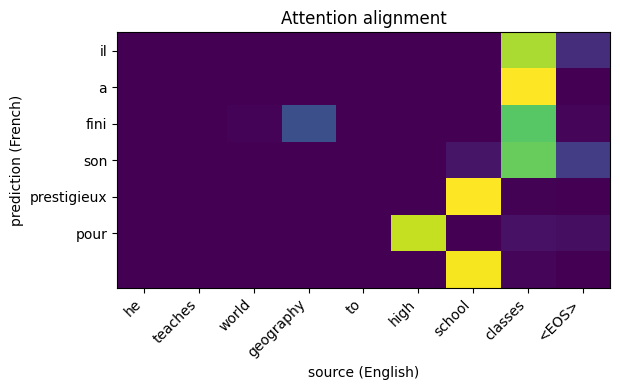

In [ ]:
attn_acc, attn_bleu = evaluate_attn(attn_encoder, attn_decoder, val_pairs,
                                    eng_vocab, fr_vocab, src_is_english=True, n_examples=5)

def plot_attention(encoder, decoder, src_txt, src_vocab, tgt_vocab):
    src = torch.tensor(src_vocab.encode(src_txt), dtype=torch.long, device=device)
    ids, attn_matrix = greedy_decode_attn(encoder, decoder, src)
    src_labels = src_txt.split() + ["<EOS>"]
    tgt_labels = [tgt_vocab.idx2word[i] for i in ids]
    fig, ax = plt.subplots(figsize=(max(4, len(src_labels)*0.7), max(4, len(tgt_labels)*0.6)))
    ax.imshow(attn_matrix.numpy(), cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(src_labels)));  ax.set_xticklabels(src_labels, rotation=45, ha="right")
    ax.set_yticks(range(len(tgt_labels)));  ax.set_yticklabels(tgt_labels)
    ax.set_xlabel("source (English)"); ax.set_ylabel("prediction (French)")
    ax.set_title("Attention alignment"); plt.tight_layout(); plt.show()

# Pick two validation sentences with no UNKs so the maps read cleanly
for en, fr in val_pairs:
    if all(w in eng_vocab.word2idx for w in en.split()):
        plot_attention(attn_encoder, attn_decoder, en, eng_vocab, fr_vocab)
        break
plot_attention(attn_encoder, attn_decoder, val_pairs[0][0], eng_vocab, fr_vocab)

Problem 3: Reversing the Language Direction (40 Points)

rebuild the loaders reversed (French→English)

In [ ]:
# Same pairs, same split — just flip source and target
rev_train_ds = TranslationDataset(train_pairs, fr_vocab, eng_vocab, src_is_english=False)
rev_val_ds   = TranslationDataset(val_pairs,   fr_vocab, eng_vocab, src_is_english=False)
rev_train_loader = DataLoader(rev_train_ds, batch_size=1, shuffle=True)
rev_val_loader   = DataLoader(rev_val_ds,   batch_size=1, shuffle=False)

# Now French is the source vocab, English is the target vocab
print(f"source (French): {len(fr_vocab)} | target (English): {len(eng_vocab)}")

source (French): 970 | target (English): 881


P3 baseline GRU, French→English

epoch 01 | train 5.0807 | val 4.7250
epoch 05 | train 1.5916 | val 4.3361
epoch 10 | train 0.1517 | val 4.5482
epoch 15 | train 0.0338 | val 4.7402
epoch 20 | train 0.0241 | val 4.9212
epoch 25 | train 0.1003 | val 5.1430
epoch 30 | train 0.0100 | val 5.3149
epoch 35 | train 0.0062 | val 5.4232
epoch 40 | train 0.0089 | val 5.5891


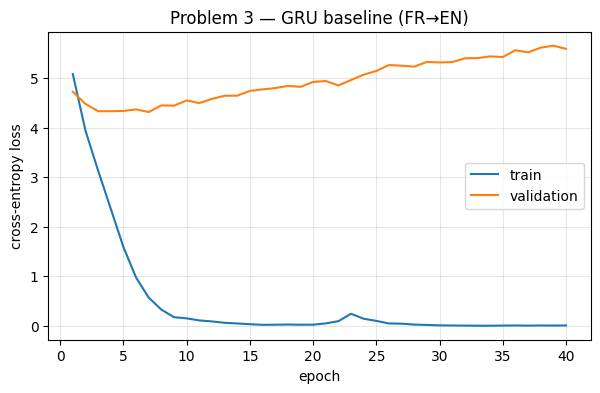

Exact-match accuracy : 0.00%  (0/111)
Average BLEU-4        : 0.1267

[FAIL] BLEU 0.067
  in  : il enseigne la géographie mondiale à des classes de lycée
  tgt : he teaches world geography to high school classes
  pred: he teaches molecular chemistry to advanced students

[FAIL] BLEU 0.181
  in  : il joue de la basse dans un groupe de jazz professionnel
  tgt : he plays bass guitar in a professional jazz band
  pred: he plays bass in a jazz band

[FAIL] BLEU 0.029
  in  : les prévisions météo annoncent de fortes chutes de neige demain
  tgt : the weather forecast predicts heavy snow tomorrow
  pred: we are definitely going to the live concert tomorrow

[FAIL] BLEU 0.570
  in  : elle adore porter de longues jupes amples en coton
  tgt : she loves to wear long flowing cotton skirts
  pred: she loves to wear long skirts

[FAIL] BLEU 0.029
  in  : ils écoutent le professeur avec une attention absolue
  tgt : they listen to the professor with absolute attention
  pred: they are planning a n

In [ ]:
hidden_size = 256
fr_encoder = EncoderGRU(len(fr_vocab), hidden_size).to(device)     # input = French vocab
fr_decoder = DecoderGRU(hidden_size, len(eng_vocab)).to(device)    # output = English vocab
criterion = nn.CrossEntropyLoss()
enc_opt = optim.Adam(fr_encoder.parameters(), lr=0.001)
dec_opt = optim.Adam(fr_decoder.parameters(), lr=0.001)

n_epochs = 40
fr_train_losses, fr_val_losses = [], []
for epoch in range(1, n_epochs + 1):
    fr_encoder.train(); fr_decoder.train(); running = 0
    for src, tgt in rev_train_loader:
        src, tgt = src[0].to(device), tgt[0].to(device)
        running += train_step(src, tgt, fr_encoder, fr_decoder, enc_opt, dec_opt, criterion)
    fr_train_losses.append(running / len(rev_train_loader))
    fr_val_losses.append(val_loss(fr_encoder, fr_decoder, rev_val_loader, criterion))
    if epoch == 1 or epoch % 5 == 0:
        print(f"epoch {epoch:02d} | train {fr_train_losses[-1]:.4f} | val {fr_val_losses[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, n_epochs + 1), fr_train_losses, label="train")
plt.plot(range(1, n_epochs + 1), fr_val_losses, label="validation")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss")
plt.title("Problem 3 — GRU baseline (FR→EN)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

# Note the flipped vocab order: source=fr_vocab, target=eng_vocab, src_is_english=False
fr_acc, fr_bleu = evaluate(fr_encoder, fr_decoder, val_pairs,
                           fr_vocab, eng_vocab, src_is_english=False, n_examples=5)

P3 attention GRU, French→English

epoch 01 | train 5.2034 | val 4.8091
epoch 05 | train 1.8262 | val 4.2666
epoch 10 | train 0.4588 | val 4.6124
epoch 15 | train 0.1805 | val 4.8402
epoch 20 | train 0.0925 | val 5.1309
epoch 25 | train 0.1384 | val 5.4831
epoch 30 | train 0.0505 | val 5.3845
epoch 35 | train 0.1808 | val 5.6033
epoch 40 | train 0.0316 | val 5.7841


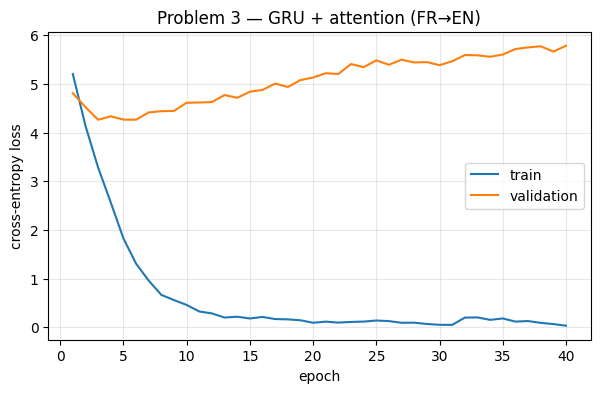

Exact-match accuracy : 0.00%  (0/111)
Average BLEU-4        : 0.1267

[FAIL] BLEU 0.069
  in  : il enseigne la géographie mondiale à des classes de lycée
  tgt : he teaches world geography to high school classes
  pred: he teaches biology to teenagers

[FAIL] BLEU 0.181
  in  : il joue de la basse dans un groupe de jazz professionnel
  tgt : he plays bass guitar in a professional jazz band
  pred: he plays bass in a jazz band

[FAIL] BLEU 0.028
  in  : les prévisions météo annoncent de fortes chutes de neige demain
  tgt : the weather forecast predicts heavy snow tomorrow
  pred: the have has a beautiful of your have

[FAIL] BLEU 0.142
  in  : elle adore porter de longues jupes amples en coton
  tgt : she loves to wear long flowing cotton skirts
  pred: she loves to dye her hair dark

[FAIL] BLEU 0.029
  in  : ils écoutent le professeur avec une attention absolue
  tgt : they listen to the professor with absolute attention
  pred: they practice a hot cup of tea



In [ ]:
fr_attn_encoder = EncoderGRU(len(fr_vocab), hidden_size).to(device)
fr_attn_decoder = AttnDecoderGRU(hidden_size, len(eng_vocab)).to(device)
enc_opt = optim.Adam(fr_attn_encoder.parameters(), lr=0.001)
dec_opt = optim.Adam(fr_attn_decoder.parameters(), lr=0.001)

n_epochs = 40
fr_attn_train_losses, fr_attn_val_losses = [], []
for epoch in range(1, n_epochs + 1):
    fr_attn_encoder.train(); fr_attn_decoder.train(); running = 0
    for src, tgt in rev_train_loader:
        src, tgt = src[0].to(device), tgt[0].to(device)
        running += train_step_attn(src, tgt, fr_attn_encoder, fr_attn_decoder, enc_opt, dec_opt, criterion)
    fr_attn_train_losses.append(running / len(rev_train_loader))
    fr_attn_val_losses.append(val_loss_attn(fr_attn_encoder, fr_attn_decoder, rev_val_loader, criterion))
    if epoch == 1 or epoch % 5 == 0:
        print(f"epoch {epoch:02d} | train {fr_attn_train_losses[-1]:.4f} | val {fr_attn_val_losses[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, n_epochs + 1), fr_attn_train_losses, label="train")
plt.plot(range(1, n_epochs + 1), fr_attn_val_losses, label="validation")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss")
plt.title("Problem 3 — GRU + attention (FR→EN)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

fr_attn_acc, fr_attn_bleu = evaluate_attn(fr_attn_encoder, fr_attn_decoder, val_pairs,
                                          fr_vocab, eng_vocab, src_is_english=False, n_examples=5)

 summary table that ties all four runs together

In [ ]:
print(f"{'Model':<28}{'Exact %':>10}{'BLEU-4':>10}")
print("-" * 48)
print(f"{'P1  EN->FR baseline':<28}{acc:>10.2f}{bleu:>10.4f}")
print(f"{'P2  EN->FR attention':<28}{attn_acc:>10.2f}{attn_bleu:>10.4f}")
print(f"{'P3  FR->EN baseline':<28}{fr_acc:>10.2f}{fr_bleu:>10.4f}")
print(f"{'P3  FR->EN attention':<28}{fr_attn_acc:>10.2f}{fr_attn_bleu:>10.4f}")

Model                          Exact %    BLEU-4
------------------------------------------------
P1  EN->FR baseline               0.00    0.1262
P2  EN->FR attention              0.90    0.1479
P3  FR->EN baseline               0.00    0.1267
P3  FR->EN attention              0.00    0.1267
